In [2]:
import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
import time
import os
import cv2
from dataPreparation import dataPrep
from imutils import paths
from sklearn.model_selection import train_test_split
from torch.nn import Module
from FCN import FCN
from unet import UNet
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss
from torch.optim import AdamW
from tqdm import tqdm
from earlyStopping import EarlyStopping

In [2]:



dataset_path = "/Users/beyzaecemerce/GitHub/thesis/drone/dataset/semantic_drone_dataset/"
image_path=dataset_path+'original_images'
masked_path = dataset_path+ 'label_images_semantic'
rgb_mask_path='/Users/beyzaecemerce/GitHub/thesis/drone/RGB_color_image_masks/RGB_color_image_masks'
TEST_SPLIT = 0.10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

In [3]:
# image = cv2.imread(image_path+"/100.jpg")
# mask=cv2.imread(masked_path+"/100.png")
# print(image.shape)
# print(mask.shape)
# figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
# ax[0].grid(False)
# ax[1].grid(False)
# ax[0].imshow(image)
# ax[1].imshow(mask)
# ax[0].set_title("Image")
# ax[1].set_title("Original Mask")
# figure.tight_layout()
# figure.show()

In [4]:
INIT_LR = 0.01
NUM_EPOCHS = 500
BATCH_SIZE = 8

INPUT_IMAGE_WIDTH = 6000
INPUT_IMAGE_HEIGHT = 4000

BASE_OUTPUT ="/Users/beyzaecemerce/GitHub/thesis/drone/output"

MODEL_PATH = os.path.join(BASE_OUTPUT, "MODEL_FCN_small.pth")
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "Train_Test_Plot.png"])
TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_path.txt"])

In [5]:
imagePaths = sorted(list(paths.list_images(image_path)))
maskPaths = sorted(list(paths.list_images(masked_path)))

split = train_test_split(imagePaths, maskPaths,test_size=TEST_SPLIT, random_state=42)

(trainImages, testImages) = split[:2]
(trainMasks, testMasks) = split[2:]

print("[INFO] saving testing image paths...")
f = open(TEST_PATHS, "w")
f.write("\n".join(testImages))
f.close()

[INFO] saving testing image paths...


In [6]:
input_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((512, 768),interpolation=cv2.INTER_NEAREST),  # Resize the input image to (height=256, width=384)
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 768)),  # Resize the mask to the same size as the input image
    transforms.ToTensor()
])

In [7]:
train = dataPrep(imagePaths=trainImages, maskPaths=trainMasks, input_transform=input_transform, mask_transform=mask_transform,n_class=23)
test = dataPrep(imagePaths=testImages, maskPaths=testMasks, input_transform=input_transform, mask_transform=mask_transform,n_class=23)


trainLoader = DataLoader(train, shuffle=False,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY,num_workers=os.cpu_count())

testLoader = DataLoader(test, shuffle=False,batch_size=BATCH_SIZE, pin_memory=PIN_MEMORY,num_workers=os.cpu_count())


In [8]:
model=FCN(23)
opt = AdamW(model.parameters(), lr=INIT_LR)
lossFunc=torch.nn.BCEWithLogitsLoss()
trainSteps = len(train) // BATCH_SIZE
testSteps = len(test) // BATCH_SIZE
H = {"train_loss": [], "test_loss": []}
early_stopping=EarlyStopping()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.1, patience=2, threshold=0.0001, threshold_mode='abs')


In [9]:
def iou(pred, target):
    ious = []
    for cls in range(23):
        pred_inds = pred == cls
        target_inds = target == cls
        print(pred_inds)
        intersection = pred_inds[target_inds].sum()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            ious.append(float('nan'))  # if there is no ground truth, do not include in evaluation
        else:
            ious.append(float(intersection) / max(union, 1))
        # print("cls", cls, pred_inds.sum(), target_inds.sum(), intersection, float(intersection) / max(union, 1))
    return ious


def pixel_acc(pred, target):
    correct = (pred == target).sum()
    total   = (target == target).sum()
    return correct / total

In [10]:
SMOOTH = 1e-6
def iou_numpy(outputs: np.array, labels: np.array):    
    outputs=outputs.astype(np.uint8)
    labels=labels.astype(np.uint8)
    intersection = (outputs & labels).sum()
    union = (outputs | labels).sum()
    
    iou = (intersection + SMOOTH) / (union + SMOOTH)    
    return iou 

In [11]:
score_dir = os.path.join("scores")
if not os.path.exists(score_dir):
    os.makedirs(score_dir)

In [12]:
print("[INFO] training the network...")
startTime = time.time()

for e in tqdm(range(NUM_EPOCHS)):
  model.train()
  totalTrainLoss = 0
  totalTestLoss = 0
  total_ious = []
  pixel_accs = []
  IU_scores    = np.zeros((NUM_EPOCHS, 23))
  pixel_scores = np.zeros(NUM_EPOCHS)

  for (i, (x, y,z)) in enumerate(trainLoader):
    (x, y) = (x.to(DEVICE), y.to(DEVICE))
    pred = model(x) 
    #pred=torch.nn.Softmax(pred,dim=1)
    loss = lossFunc(pred, y)
    #iou_score += mIoU(pred, y)
    #accuracy += pixel_accuracy(pred, y)
    loss.backward()
    opt.step()
    opt.zero_grad()
    totalTrainLoss += loss
    #print("Step",i)

  with torch.no_grad():
    model.eval()
    for (x, y, z) in testLoader:
      (x, y) = (x.to(DEVICE), y.to(DEVICE))
      pred = model(x)
      totalTestLoss += lossFunc(pred, y)
      pred = pred.data.cpu().numpy()
      N, _, h, w = pred.shape # 8 ,24, 256 ,512
      pred = pred.transpose(0, 2, 3, 1).reshape(-1, 23).argmax(axis=1).reshape(N, h, w) #(8, 192, 256)
      z=z.detach().cpu().numpy()
      
      #target = batch['l'].cpu().numpy().reshape(N, h, w)
      for p, t in zip(pred, z):
          total_ious.append(iou_numpy(p, t))
          pixel_accs.append(pixel_acc(p, t))

    total_ious = np.array(total_ious).T  # n_class * val_len
    ious = np.nanmean(total_ious)
    pixel_accs_mean = np.array(pixel_accs).mean()
    print("epoch{}, pixel_accs_mean : {}, pix_accs: {}, meanIoU: {}".format(e+1, pixel_accs_mean, pixel_accs,ious))

  avgTrainLoss = totalTrainLoss / trainSteps
  avgTestLoss = totalTestLoss / testSteps
  H["train_loss"].append(avgTrainLoss.cpu().detach().numpy())
  H["test_loss"].append(avgTestLoss.cpu().detach().numpy())

  scheduler.step(avgTestLoss)
  early_stopping(avgTrainLoss,avgTestLoss)
  
        
  if early_stopping.early_stop:
      print("Early stopping")
      break
  print("[INFO] EPOCH: {}/{}".format(e + 1, NUM_EPOCHS))
  print("Train loss: {:.6f}, Test loss: {:.4f}".format(avgTrainLoss, avgTestLoss))
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

[INFO] training the network...


  0%|          | 1/500 [27:22<227:42:57, 1642.84s/it]

epoch1, pixel_accs_mean : 6.29425048828125e-06, pix_accs: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.7974446614583332e-05, 0.0, 7.62939453125e-06, 0.0, 1.52587890625e-05, 0.0, 0.0, 0.0, 0.00017293294270833334, 5.086263020833333e-06, 0.0, 0.0, 0.0, 0.0, 1.2715657552083334e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.5431315104166665e-06, 7.62939453125e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], meanIoU: 1.5269782852504583e-13
[INFO] EPOCH: 1/500
Train loss: 0.293000, Test loss: 0.0074


  0%|          | 2/500 [51:46<212:41:16, 1537.50s/it]

epoch2, pixel_accs_mean : 1.2461344401041668e-05, pix_accs: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.883707682291667e-05, 0.0, 2.0345052083333332e-05, 0.0, 7.62939453125e-05, 0.0, 0.0, 0.0, 0.00018310546875, 2.288818359375e-05, 0.0, 0.0, 0.0, 0.0, 8.392333984375e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0172526041666666e-05, 2.288818359375e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], meanIoU: 1.5356242712883177e-13
[INFO] EPOCH: 2/500
Train loss: 0.002934, Test loss: 0.0017


  1%|          | 3/500 [1:19:41<220:54:07, 1600.10s/it]

epoch3, pixel_accs_mean : 4.774729410807292e-05, pix_accs: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00029754638671875, 2.5431315104166665e-06, 3.814697265625e-05, 0.0, 0.0003763834635416667, 2.5431315104166665e-06, 0.0, 0.0, 0.0003382364908854167, 0.0003153483072916667, 2.5431315104166665e-06, 0.0, 0.0, 0.0, 0.0003814697265625, 2.5431315104166665e-06, 0.0, 2.5431315104166665e-06, 2.5431315104166665e-06, 0.0, 2.5431315104166665e-06, 3.814697265625e-05, 0.0, 0.0, 3.814697265625e-05, 6.866455078125e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], meanIoU: 1.6556833629610114e-13
[INFO] EPOCH: 3/500
Train loss: 0.001384, Test loss: 0.0012


In [ ]:
plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["test_loss"], label="test_loss")
plt.title("Training Loss on Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")
plt.savefig(PLOT_PATH)
torch.save(model, MODEL_PATH)

In [ ]:
from prediction import make_predictions

[INFO] loading up test image paths...
[INFO] load up model...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[-27.78158  -27.190231 -25.362814 ...  16.735767  16.836739  17.254622]
[11.054235    9.861822    9.204468   ...  0.92000234  0.7535062
  0.89555013]
[11  9  9 ...  2  2  1]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
(1, 512, 768)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22]


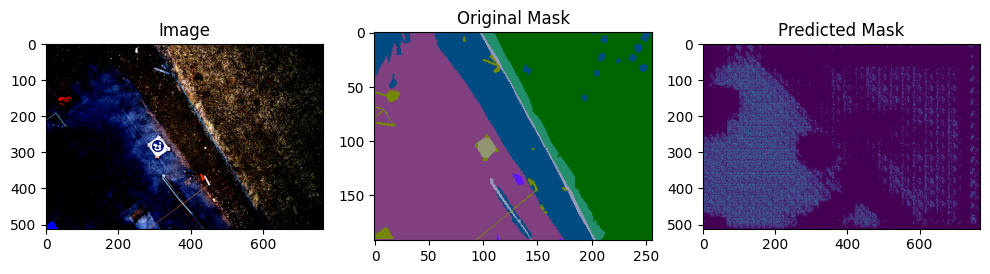

In [ ]:
print("[INFO] loading up test image paths...")
imagePaths = open(TEST_PATHS).read().strip().split("\n")
imagePaths = np.random.choice(imagePaths, size=1)
# load our model from disk and flash it to the current device
print("[INFO] load up model...")
model_p = torch.load(MODEL_PATH,map_location=torch.device('cpu'))
# iterate over the randomly selected test image paths
for path in imagePaths:
	# make predictions and visualize the results
	make_predictions(model_p, path,rgb_mask_path,input_transform)

#### orijinal masklar RGB olanlardan alınacak. Predict olanlar RGB'ye çevirilecek
#### earlystopping ayarlanacak.